In [73]:
import json
import pandas as pd
import matplotlib.pyplot as plt
with open('params_history.json') as f:
    data = json.load(f)

In [74]:
data = pd.DataFrame(data)
data.columns = ['epoch', 'tau','delta','c_cong','c_free', 'v_thr', 'v_delta','train_rmse','val_rmse']

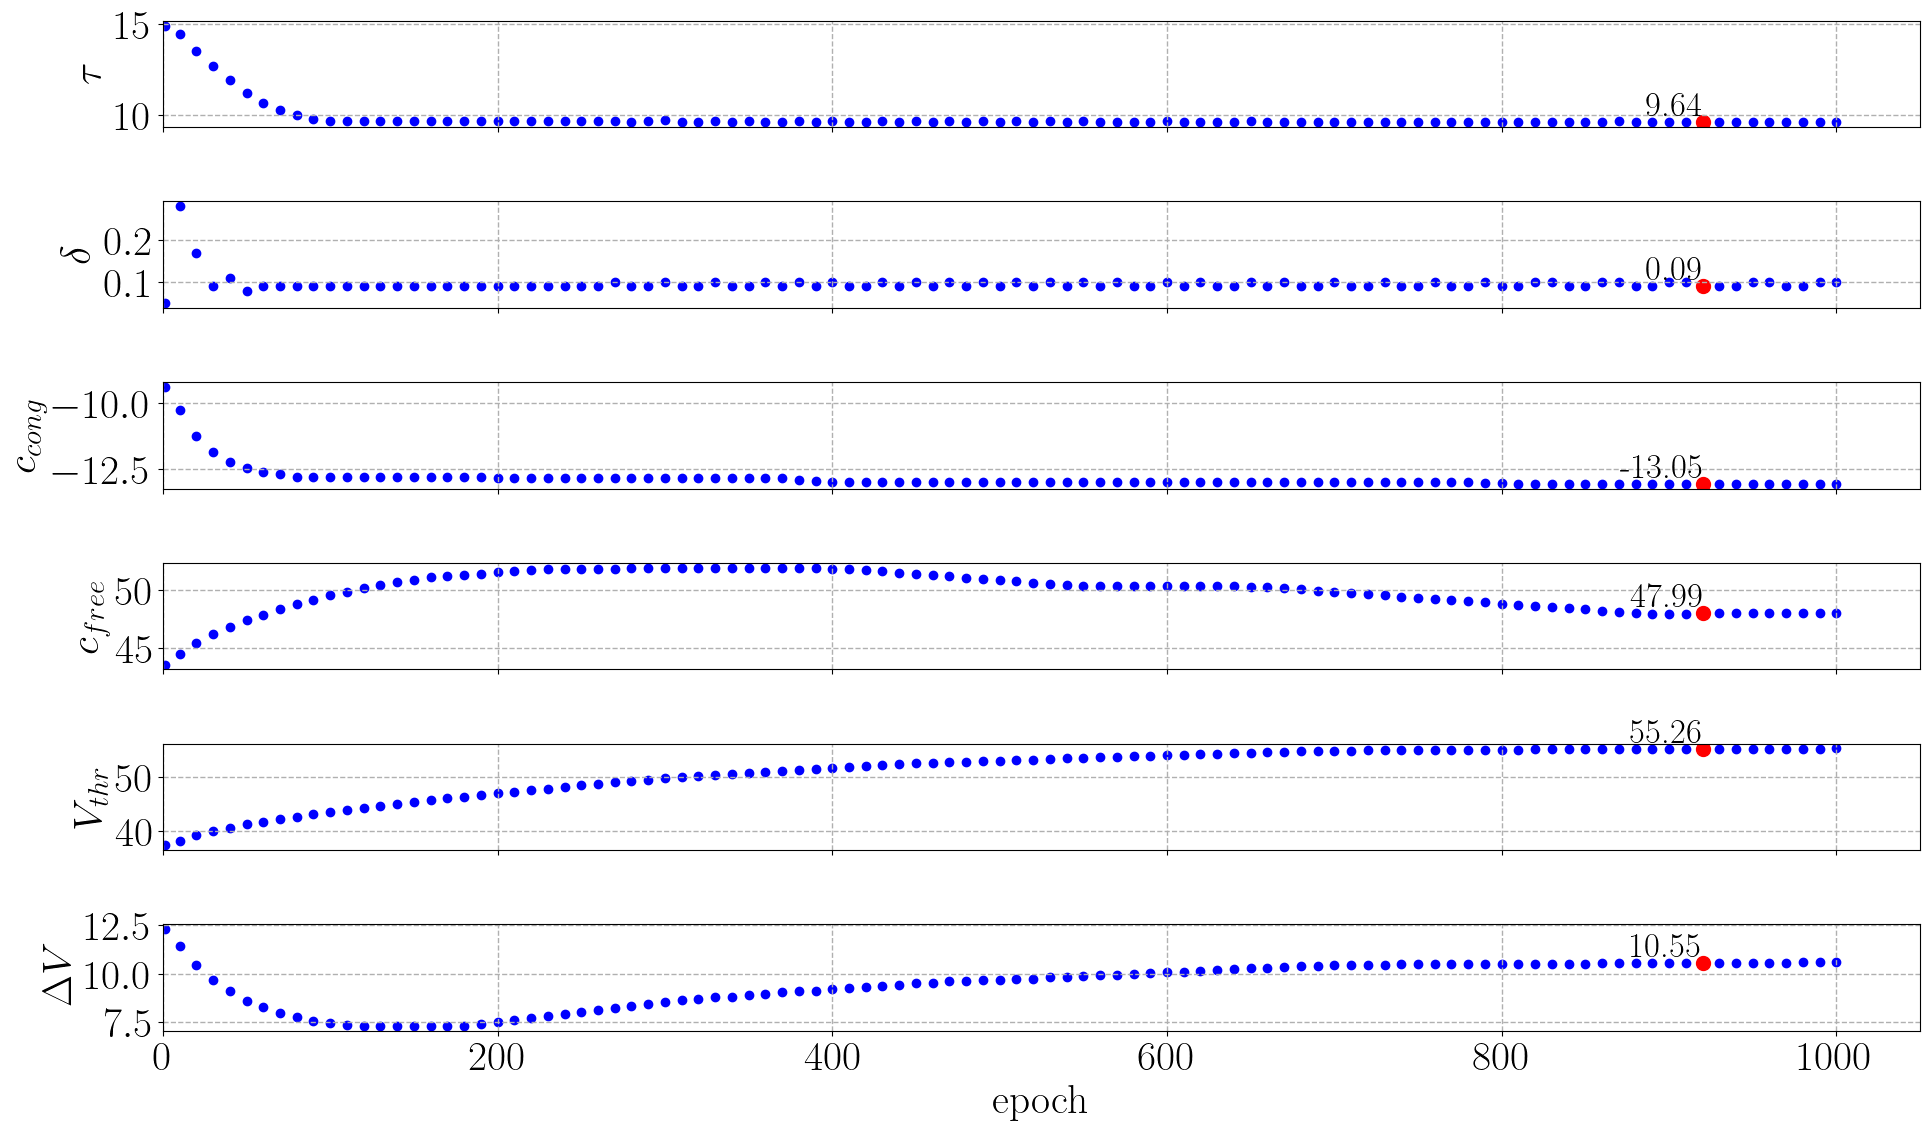

In [77]:
import matplotlib.pyplot as plt

# Set global font settings
plt.rc('font', family='serif')
plt.rc('font', size=30)
plt.rc('text', usetex=True)

# Create figure and subplots
fig, axs = plt.subplots(6, 1, figsize=(20, 12), sharex=True)  # 6 rows, 1 column
loc = data['val_rmse'].idxmin()
# Plot each dataset
axs[0].scatter(data['epoch'], data['tau'], label='tau', color='blue')
axs[0].set_ylabel(r'$\tau$')
axs[0].set_xlim(0,)
# show the value of data['tau'] of the last epoch
# mark the minimum point with a red dot
axs[0].scatter(data['epoch'].iloc[loc], data['tau'].iloc[loc], color='red', s=100)
axs[0].text(data['epoch'].iloc[loc], data['tau'].iloc[loc], f'{data["tau"].iloc[loc]:.2f}', fontsize=25, ha='right', va='bottom')
# add grid lines
axs[0].grid(True, which='both', linestyle='--', linewidth=1)

axs[1].scatter(data['epoch'], data['delta'], label='delta', color='blue')
axs[1].set_ylabel(r'$\delta$')
axs[1].set_xlim(0,)
axs[1].scatter(data['epoch'].iloc[loc], data['delta'].iloc[loc], color='red', s=100)
axs[1].text(data['epoch'].iloc[loc], data['delta'].iloc[loc], f'{data["delta"].iloc[loc]:.2f}', fontsize=25, ha='right', va='bottom')
axs[1].grid(True, which='both', linestyle='--', linewidth=1)

axs[2].scatter(data['epoch'], -data['c_cong'], label='c\_cong', color='blue')
axs[2].set_ylabel(r'$c_{cong}$')
axs[2].set_xlim(0,)
axs[2].scatter(data['epoch'].iloc[loc], -data['c_cong'].iloc[loc], color='red', s=100)
axs[2].text(data['epoch'].iloc[loc], -data['c_cong'].iloc[loc], f'{-data["c_cong"].iloc[loc]:.2f}', fontsize=25, ha='right', va='bottom')
axs[2].grid(True, which='both', linestyle='--', linewidth=1)

axs[3].scatter(data['epoch'], -data['c_free'], label='c\_free', color='blue')
axs[3].set_ylabel(r'$c_{free}$')
axs[3].set_xlim(0,)
axs[3].scatter(data['epoch'].iloc[loc], -data['c_free'].iloc[loc], color='red', s=100)
# show the value of data['c_free'] of the last epoch
axs[3].text(data['epoch'].iloc[loc], -data['c_free'].iloc[loc], f'{-data["c_free"].iloc[loc]:.2f}', fontsize=25, ha='right', va='bottom')
axs[3].grid(True, which='both', linestyle='--', linewidth=1)

axs[4].scatter(data['epoch'], data['v_thr'], label='v\_thr', color='blue')
axs[4].set_ylabel(r'$V_{thr}$')  # <-- corrected here: you need braces around thr
axs[4].set_xlim(0,)
axs[4].scatter(data['epoch'].iloc[loc], data['v_thr'].iloc[loc], color='red', s=100)
# show the value of data['v_thr'] of the last epoch
axs[4].text(data['epoch'].iloc[loc], data['v_thr'].iloc[loc], f'{data["v_thr"].iloc[loc]:.2f}', fontsize=25, ha='right', va='bottom')
axs[4].grid(True, which='both', linestyle='--', linewidth=1)

axs[5].scatter(data['epoch'], data['v_delta'], label='v\_delta', color='blue')
axs[5].set_ylabel(r'$\Delta V$')
axs[5].set_xlim(0,)
axs[5].scatter(data['epoch'].iloc[loc], data['v_delta'].iloc[loc], color='red', s=100)
# show the value of data['v_delta'] of the last epoch
axs[5].text(data['epoch'].iloc[loc], data['v_delta'].iloc[loc], f'{data["v_delta"].iloc[loc]:.2f}', fontsize=25, ha='right', va='bottom')
axs[5].set_xlabel('epoch')  # only set xlabel on the last subplot
axs[5].grid(True, which='both', linestyle='--', linewidth=1)

# Adjust layout
plt.tight_layout()
plt.savefig('params_iteration.pdf', dpi=300, bbox_inches='tight')
plt.show()


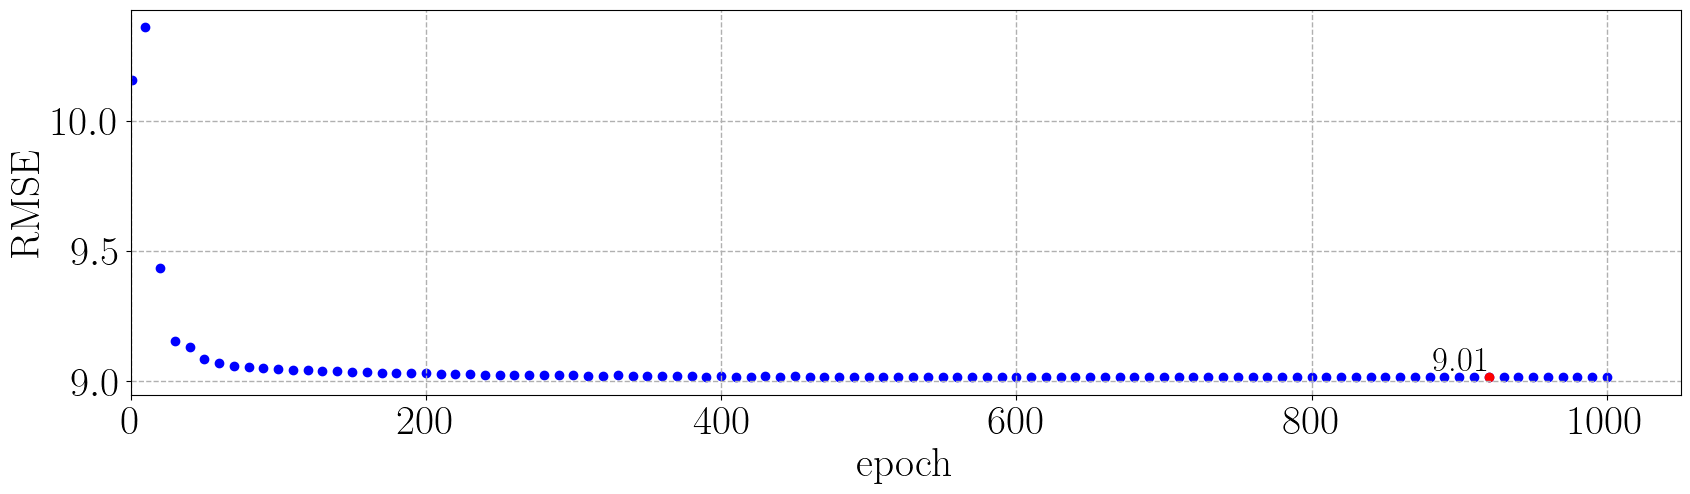

In [72]:
plt.figure(figsize=(20, 5))
plt.scatter(data['epoch'], data['val_rmse'], label='val_rmse', color='blue')
# show the best train_rmse result
plt.scatter(data['epoch'].iloc[data['val_rmse'].idxmin()], data['val_rmse'].min(), color='red')
plt.text(data['epoch'].iloc[data['val_rmse'].idxmin()], data['val_rmse'].min(), f'{data["val_rmse"].min():.2f}', fontsize=25, ha='right', va='bottom')
plt.ylabel('RMSE')
plt.xlabel('epoch')
plt.xlim(0,)
plt.grid(True, which='both', linestyle='--', linewidth=1)
plt.savefig('rmse_iteration.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [79]:
import json
import pandas as pd
import matplotlib.pyplot as plt
for lane in range(1, 5):
    with open(f'params_history_lane{lane}.json') as f:
        data = json.load(f)
    data = pd.DataFrame(data)
    data.columns = ['epoch', 'tau','delta','c_cong','c_free', 'v_thr', 'v_delta','train_rmse','val_rmse']
    # print the best parameters on val_rmse
    loc = data['val_rmse'].idxmin()
    print(f"Best parameters on val_rmse for lane {lane}: {data.iloc[loc]}")

Best parameters on val_rmse for lane 1: epoch         1620.000000
tau              9.650000
delta            0.090000
c_cong          13.059999
c_free         -48.000000
v_thr           55.639999
v_delta         10.790000
train_rmse       9.014214
val_rmse         9.014202
Name: 162, dtype: float64
Best parameters on val_rmse for lane 2: epoch         1930.000000
tau              7.390000
delta            0.100000
c_cong          12.320000
c_free         -50.340000
v_thr           50.039997
v_delta          9.880000
train_rmse       8.306893
val_rmse         8.300543
Name: 193, dtype: float64
Best parameters on val_rmse for lane 3: epoch         1230.000000
tau              9.599999
delta            0.080000
c_cong          12.750000
c_free         -59.160000
v_thr           47.209999
v_delta         10.370000
train_rmse       7.941942
val_rmse         7.936021
Name: 123, dtype: float64
Best parameters on val_rmse for lane 4: epoch         2000.000000
tau             12.540000
delta   